# Check the deconvolution logic for any issues that could create this DG1 enrichment artifact
March 1, 2024

Is there a bug in the deconvolution? Could there be a problem with how the sum of squares is computed?


Could it be the same issue as to why there was difficulty in deconvolving the gene expression data? I wonder because when I deconvolve a vector of ones, the model enriches DG1. But when I deconvolve a vector of 100s, the model deconvolves values around 100 and the small differences are no longer amplified...

In [12]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from cc_src.chromatin_model import load_chromatin_model_from_disk

chromatin_dir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'
gene_name = 'SSK22'

chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


In [101]:
chromatin_model.create_deconvolution_bins()
chromatin_model.G = chromatin_model.G*5

In [102]:
chromatin_model.gamma = 0.006*5

In [103]:
chromatin_model.deconvolve(verbose=True)

Deconvolving with gamma=0.03, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 01 03:15:50 PM: Your problem has 181600 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 01 03:15:50 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 01 03:15:50 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 01 03:15:50 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 01 03:15:50 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 01 03:15:50 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixSt

(CVXPY) Mar 01 03:17:05 PM: 25  1.0e-02  2.0e-02  5.8e-04  2.94e-01   3.925901110e+03   3.925903347e+03   1.0e-02  27.73 
(CVXPY) Mar 01 03:17:05 PM: 26  8.3e-03  1.7e-02  4.5e-04  2.55e-01   3.922330941e+03   3.922332949e+03   8.3e-03  28.26 
(CVXPY) Mar 01 03:17:05 PM: 27  7.4e-03  1.5e-02  3.9e-04  2.11e-01   3.920186330e+03   3.920188234e+03   7.4e-03  28.62 
(CVXPY) Mar 01 03:17:06 PM: 28  5.8e-03  1.2e-02  2.9e-04  2.01e-01   3.915706295e+03   3.915707973e+03   5.8e-03  29.07 
(CVXPY) Mar 01 03:17:06 PM: 29  5.4e-03  1.1e-02  2.7e-04  1.84e-01   3.914196327e+03   3.914197943e+03   5.4e-03  29.44 
(CVXPY) Mar 01 03:17:07 PM: 30  4.8e-03  9.6e-03  2.3e-04  1.78e-01   3.911913599e+03   3.911915125e+03   4.8e-03  29.80 
(CVXPY) Mar 01 03:17:07 PM: 31  4.4e-03  8.9e-03  2.1e-04  1.66e-01   3.910447891e+03   3.910449364e+03   4.4e-03  30.16 
(CVXPY) Mar 01 03:17:07 PM: 32  4.0e-03  8.0e-03  1.9e-04  1.58e-01   3.908330737e+03   3.908332138e+03   4.0e-03  30.52 
(CVXPY) Mar 01 03:17:08 

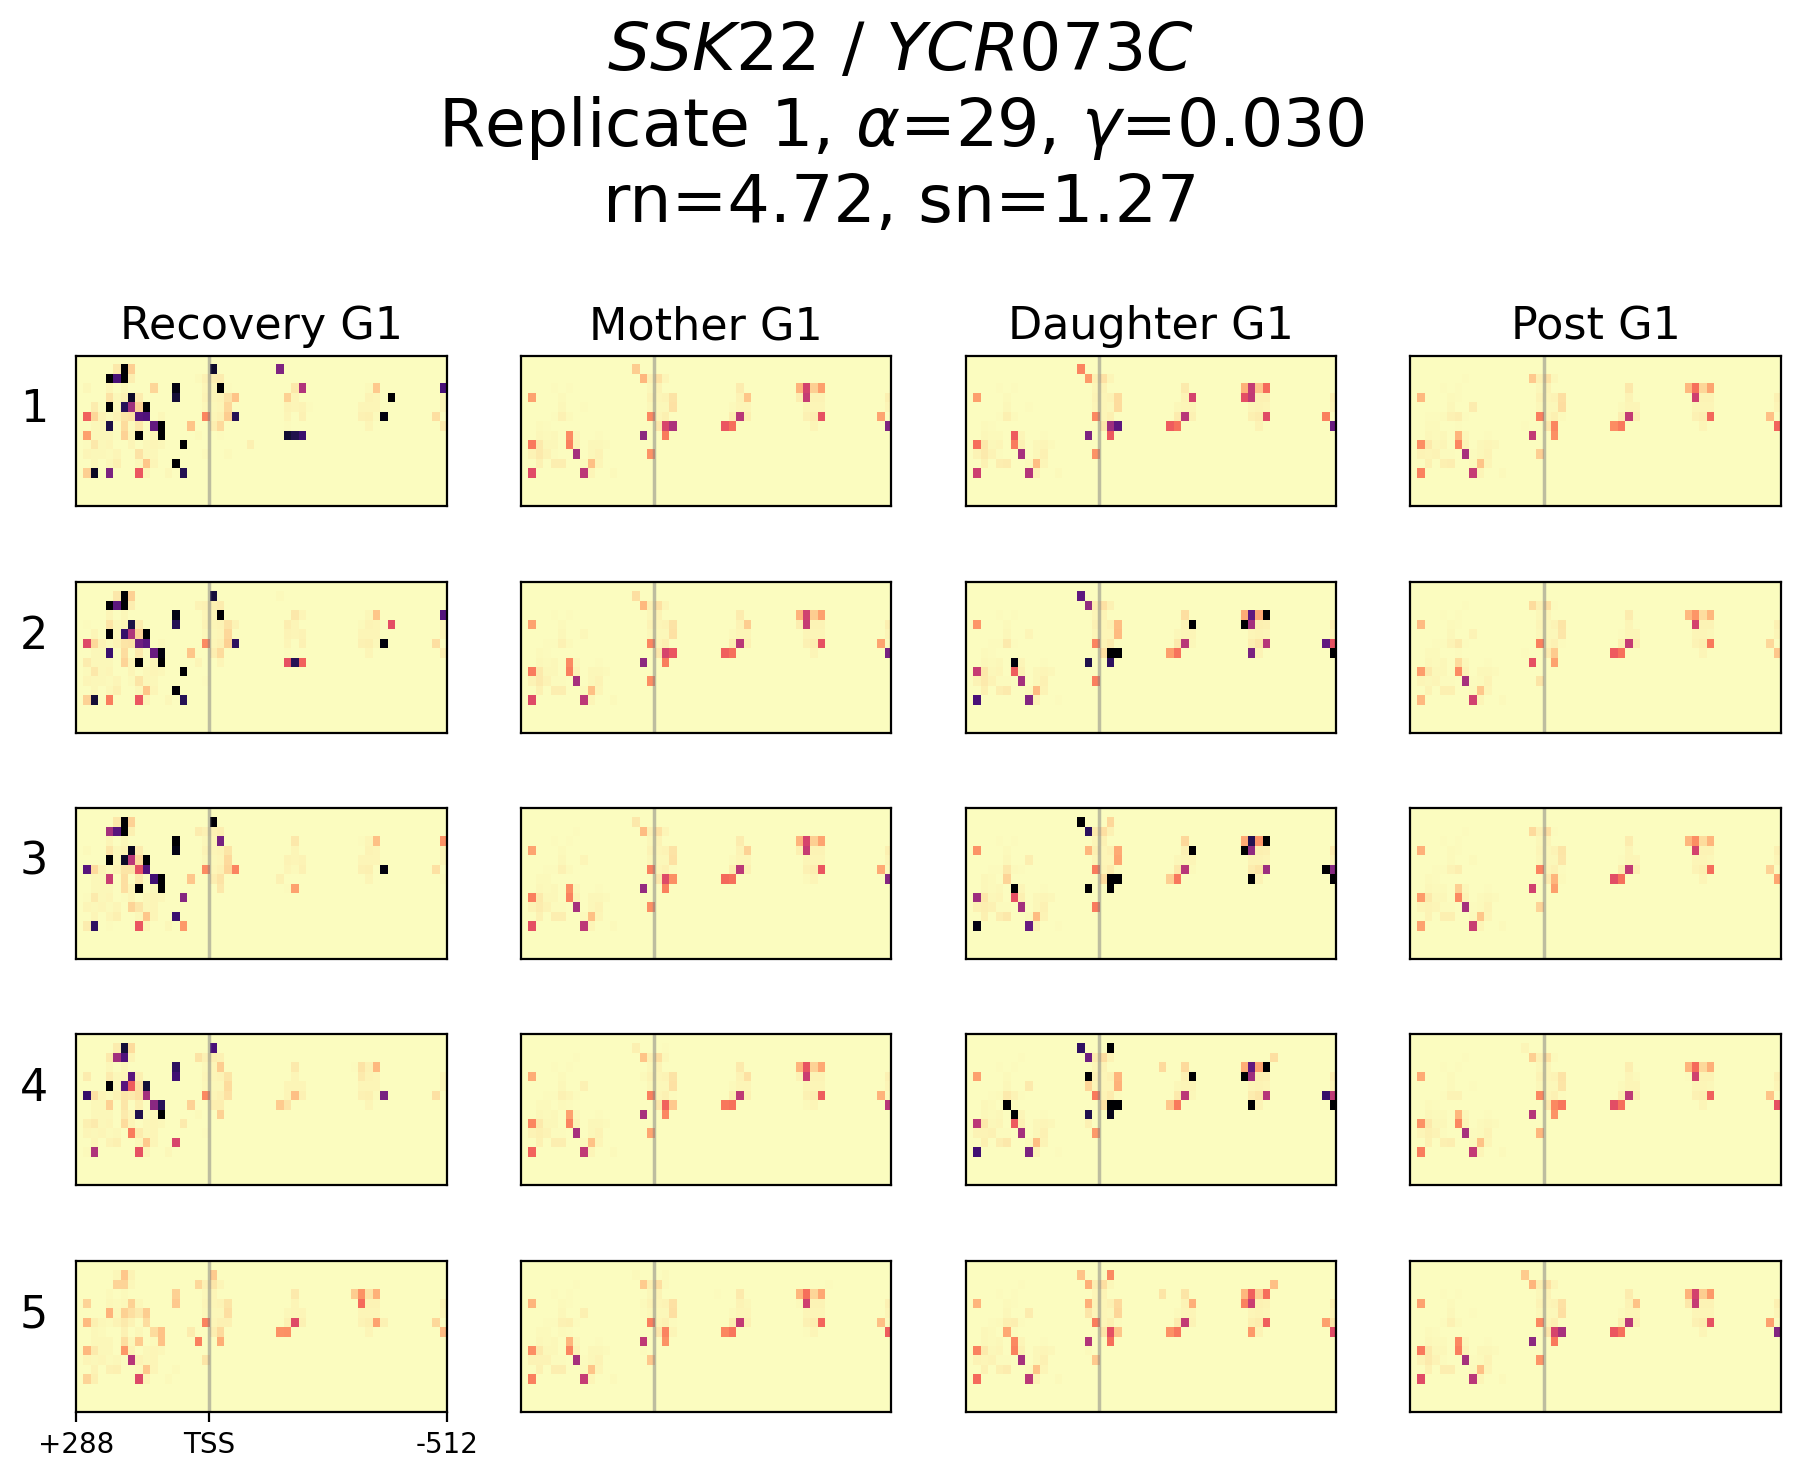

In [104]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=10)

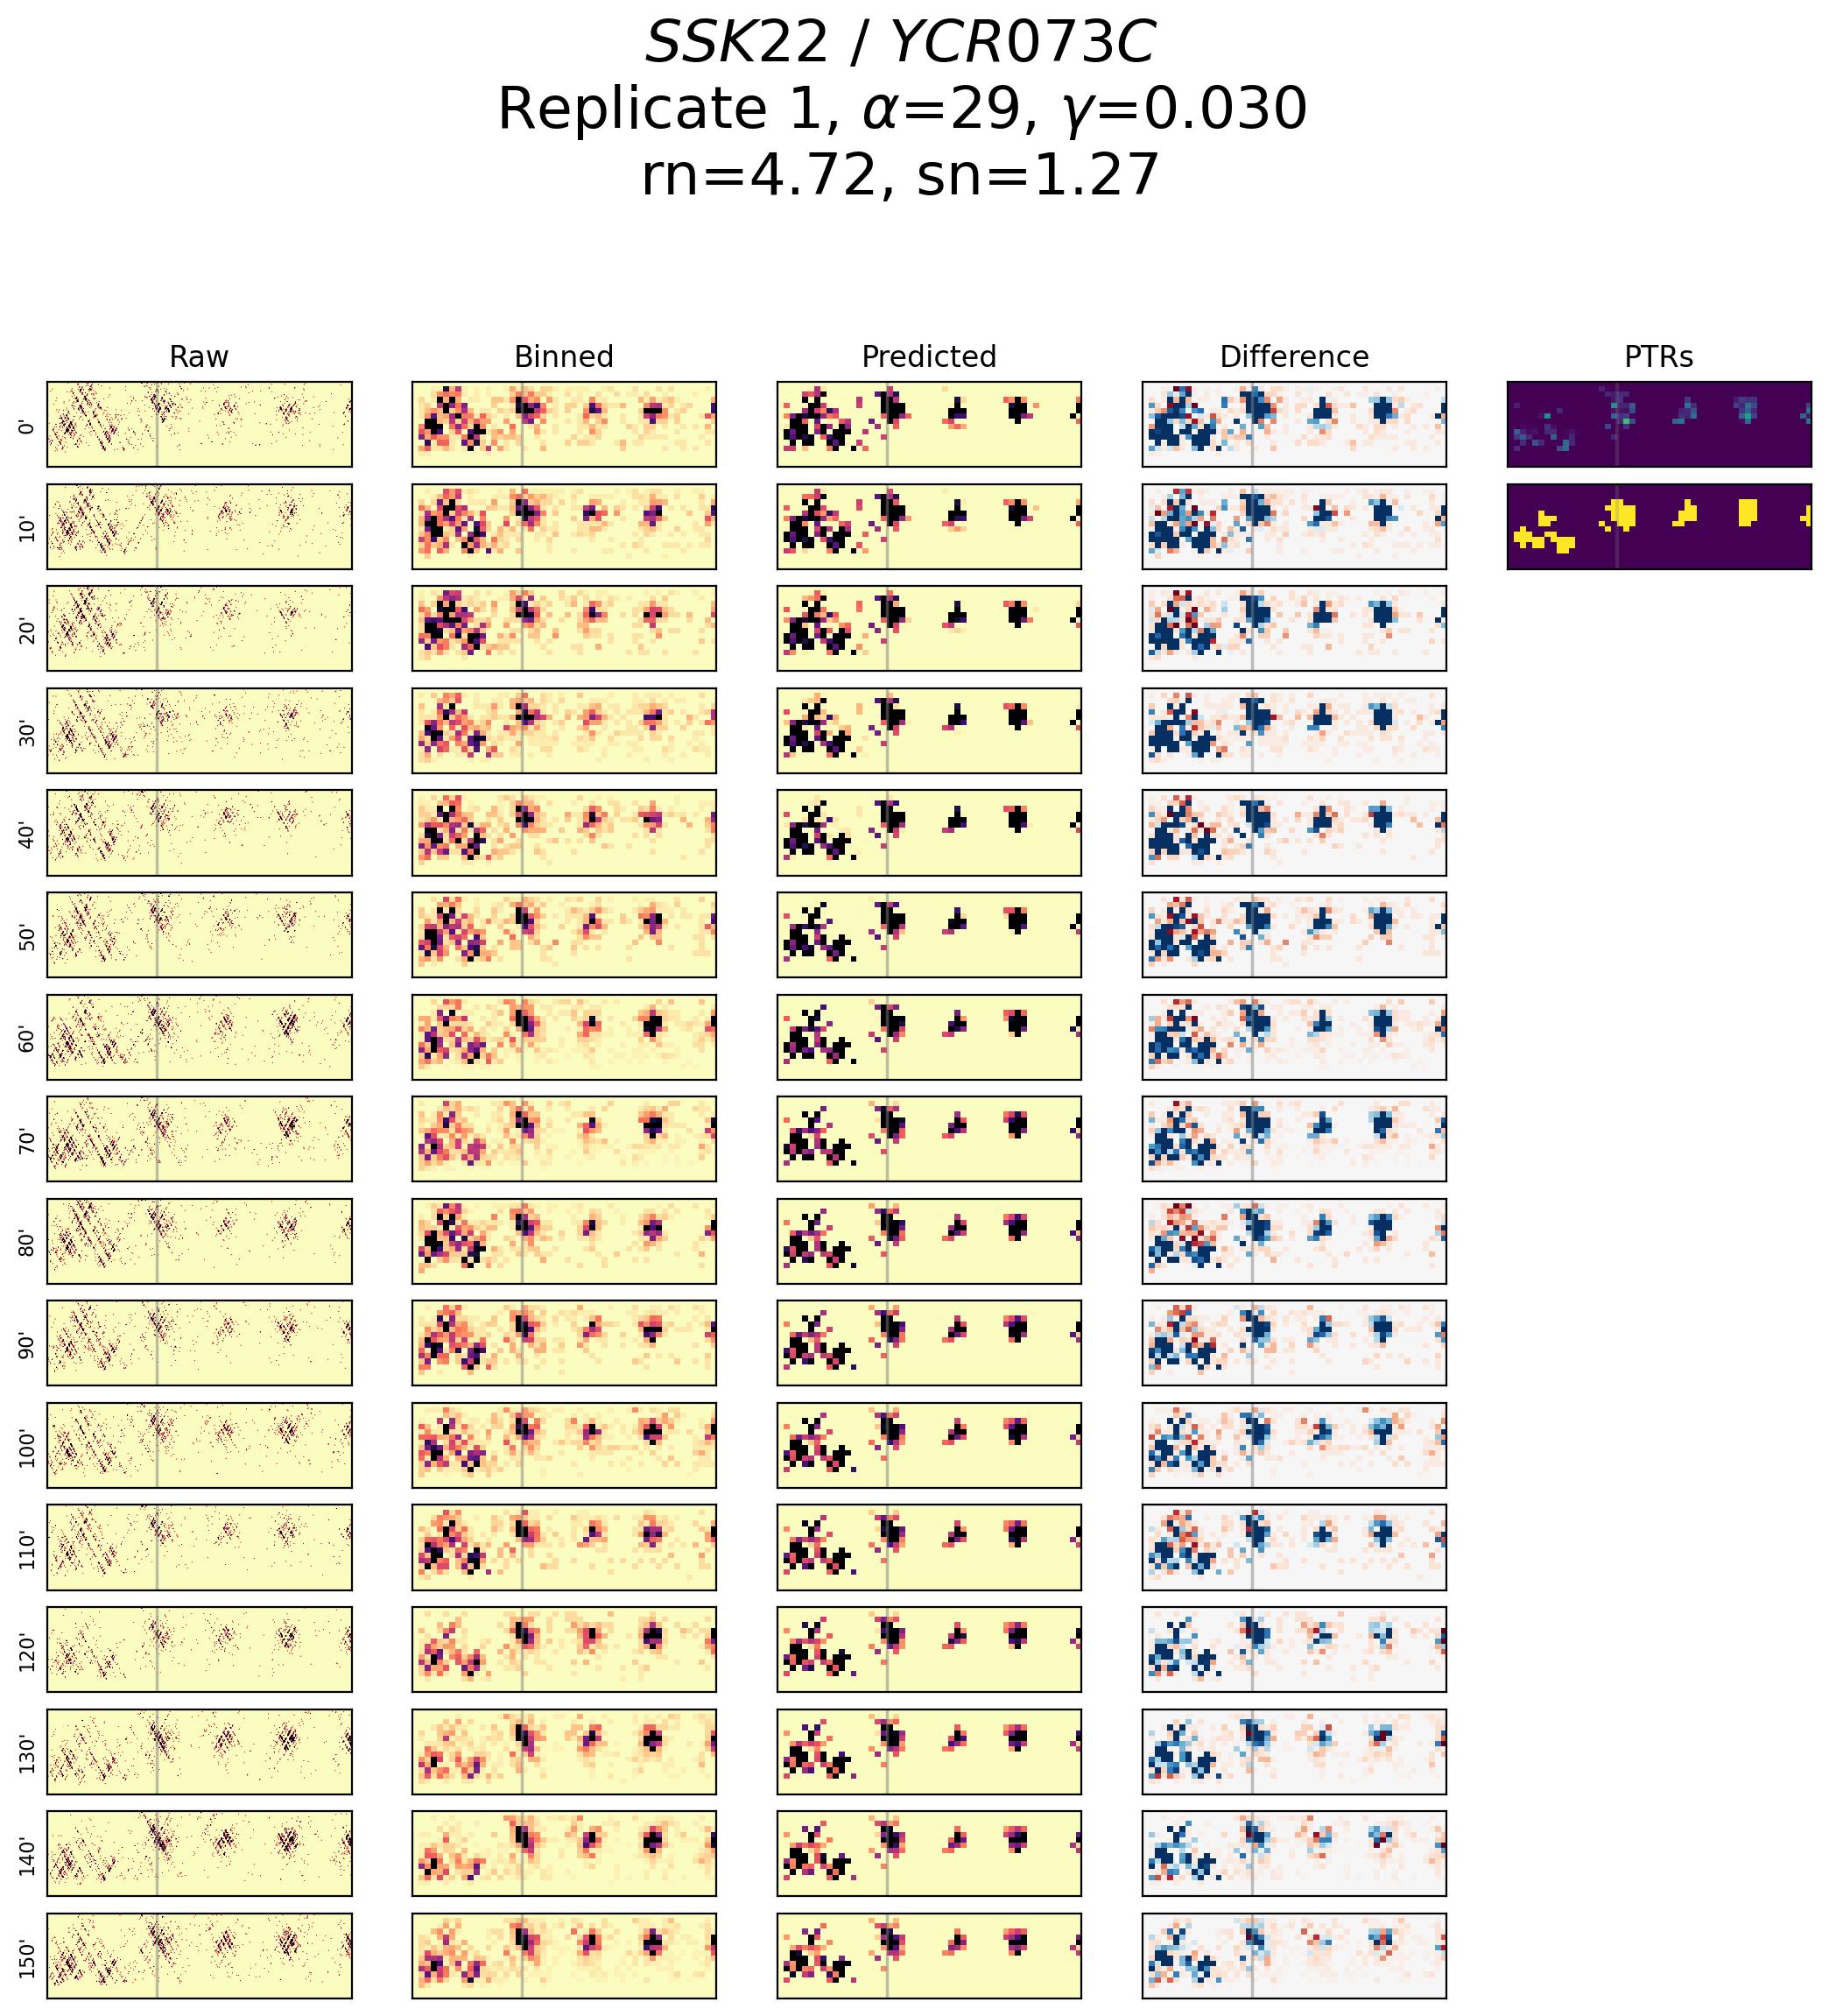

In [106]:
fig = chromatin_model.plot_prediction_comparison()